# **Apparel Classification [Special Case]**

---

We have already seen how the Apparel Classification model performs when trained with 11k images. Now let's try the same problem with a much smaller dataset of just 500 images.

## Dataset Preparation

This dataset is a modified subset of the larger <a href="https://www.kaggle.com/trolukovich/apparel-images-dataset" target="_blank">Apparel images dataset</a>. It has 500 apparel images for training and 150 for validation for the apparel classification.

We have not changed the test images and are using the same 1143 images from the previous solution. Thus, we can compare the results from before.

The training classes include :

1. Dress: 100 Images
2. Pants: 100 Images
3. Shirt: 100 images
4. Shoes: 100 images
5. Shorts: 100 Images

Directory structure:
```
train
├── class1
|   ├── img1
|   └── ...
├── class2
└── ...
val
└── ...
test
└── ...
```

<a href="https://www.dropbox.com/sh/dmjj4tfz3qk4zpu/AACy-H1cHYsEpkP94p9W6hvQa?dl=1" target="_blank">Dataset Link</a>

### Download Dataset

In [1]:
# Download the dataset
!wget -O mini-dataset.zip "https://www.dropbox.com/sh/dmjj4tfz3qk4zpu/AACy-H1cHYsEpkP94p9W6hvQa?dl=1"

# Extract the dataset
!unzip -q -u mini-dataset.zip

--2025-11-16 22:48:53--  https://www.dropbox.com/sh/dmjj4tfz3qk4zpu/AACy-H1cHYsEpkP94p9W6hvQa?dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.3.18, 2620:100:601b:18::a27d:812
Connecting to www.dropbox.com (www.dropbox.com)|162.125.3.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fo/u73l3mbup9af9pgdq7vcp/AESatmGBQhz08Fx_6InctlU?rlkey=i1gdutalie0bnl7tumplhrx27&dl=1 [following]
--2025-11-16 22:48:54--  https://www.dropbox.com/scl/fo/u73l3mbup9af9pgdq7vcp/AESatmGBQhz08Fx_6InctlU?rlkey=i1gdutalie0bnl7tumplhrx27&dl=1
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uce1b3f25872833d83d7720ada67.dl.dropboxusercontent.com/zip_download_get/CYuqNFlBp201ehKAfxbu_VYknA7c2zUgFhohxkl502okoyZ89OsK-cJcUuYU8grEjrYDUXJMG6zEJy38HOFIuUkeeaIky2oWHdNergMOY_zsGg# [following]
--2025-11-16 22:48:55--  https://uce1b3f25872833d83d7720ada67.dl.dropboxusercontent.com/zip_

## Import Libraries

Let us import all the required libraries

In [2]:
# Importing Libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Input, Softmax, Dense,Dropout,BatchNormalization,Flatten
from tensorflow.keras.models import Model
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

2025-11-16 22:49:58.386369: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-16 22:49:58.730173: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-16 22:50:00.048166: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Loading Data


In Keras, **Image Data Generator** provides real-time data augmentation. It generates augmented images on the fly while the model is still training, ensuring that the model receives new variations of the images at each epoch.

We have used the images, leaving all other parameters as default. One may use different augmentation techniques by changing the values of the various parameters accordingly.

In [3]:
# Defining Data Generator
gen = ImageDataGenerator()

**Batch Size** refers to number of images in a batch. Loading the images in batches helps us save memory. Here will have batch size of 8, which means there will be 8 images in a batch.

**Seed** is used for random shuffling and transformations.

In [4]:
# Defining  Batch Size and seed
BATCH_SIZE = 8
SEED = 21

We will now generate the dataset. The input image size is set to 224x224 pixels. The class mode is "categorical" as we have 5 different classes of images.

In [6]:
# Acquring Training images from the directory using flow_from_directory() method.
train_datagen = gen.flow_from_directory(directory = 'train',
                                        target_size = (224, 224),
                                        color_mode = "rgb",
                                        classes = None,
                                        class_mode = "categorical",
                                        batch_size = BATCH_SIZE,
                                        shuffle = True,
                                        seed = SEED,
                                        interpolation = "nearest")

Found 500 images belonging to 5 classes.


In [7]:
# Acquring Validation images from the directory using flow_from_directory() method.
val_datagen = gen.flow_from_directory(directory = 'val',
                                      target_size = (224, 224),
                                      color_mode = "rgb",
                                      classes = None,
                                      class_mode = "categorical",
                                      batch_size = BATCH_SIZE,
                                      shuffle = True,
                                      seed = SEED,
                                      interpolation = "nearest")

Found 150 images belonging to 5 classes.


In [8]:
# Acquring Testing images from the directory using flow_from_directory() method.
test_datagen = gen.flow_from_directory(directory = 'test',
                                       target_size = (224, 224),
                                       color_mode = "rgb",
                                       classes = None,
                                       class_mode = "categorical",
                                       batch_size = 1,
                                       shuffle = False, # Here Shuffle is set to False, so that we can test our model.
                                       seed = SEED,
                                       interpolation = "nearest")

Found 1163 images belonging to 5 classes.


Defining class names in a list to help with printing

In [9]:
# Classes of images in test dataset
classes = ['Dress', 'Pants', 'Shirt', 'Shoes', 'Shorts']

Let us now take a peek at a few images from the training set.

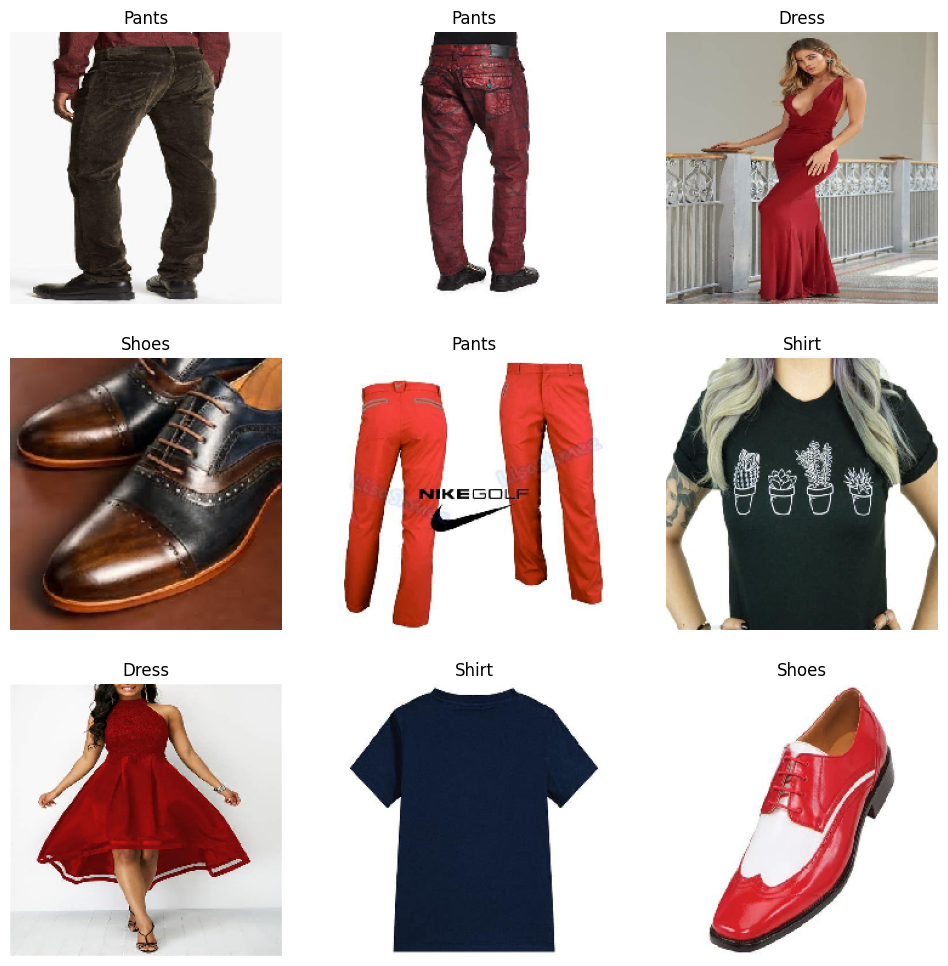

In [10]:
# Preparing the Samples and Plot for displaying output

# Create figure
fig = plt.figure(figsize = (12, 12))
for i in range(9):
  plt.subplot(330 + 1 + i)
  img, label = next(train_datagen)

  label = label[0].astype('uint8')
  label = np.squeeze(label)
  label = np.argmax(label, axis = 0)

  plt.axis('off')
  plt.imshow(img[0].astype(np.uint8))
  plt.title(classes[label])

# Displaying the figure
plt.show()

## **Initialize Pre-trained Model**

For this task, we will be using the **EfficientNet-B7** classification model.
EfficientNets are state-of-the-art image classification models and significantly outperform other ConvNets.

EfficientNet-B7 achieves 84.4% top-1 accuracy on ImageNet Dataset but being 8.4x smaller and 6.1x faster than GPipe.

Let us now import the EfficientNet B7 model pre-trained on Imagenet Dataset. Here we have set the input image size to be 224x224 pixels and kept the pooling layer to be GlobalMaxPooling2D

In [11]:
# Importing EfficientNet B7 Model
image_model = tf.keras.applications.EfficientNetB7(include_top = False,
                                                   weights ='imagenet',
                                                   input_shape = (224, 224, 3),
                                                   pooling = 'max')

I0000 00:00:1763355370.093603    9925 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21456 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9


258076736/258076736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


We can see the model layers and output shapes using the model summary.

In [12]:
# Printing Model Summary
print(image_model.summary())

Model: "efficientnetb7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      1,728 │ stem_conv_pad[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        256 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        576 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        256 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 64)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 64)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 16)  │      1,040 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 64)  │      1,088 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 64)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      2,048 │ block1a_se_excit

 Total params: 64,097,687 (244.51 MB)

 Trainable params: 63,786,960 (243.33 MB)

 Non-trainable params: 310,727 (1.19 MB)

None


Now we add Dense layers to the pre-trained model. We will also add Dropout and BatchNormalization to reduce overfitting.

We will then compile the model with the optimizer of our choice and some other hyperparameters.

We have used Adam Optimizer with an initial learning rate of 0.0001, `categorical_crossentropy` as loss function and `accuracy` as the metric.

In [13]:
# Adding Dense, BatchNorm and Droupout layers to base model
# to have output for 5 Class Classification
x = Dense(1024, activation = 'relu')((image_model.output))
x = Dropout(0.5)(x)
x = Dense(512, activation = 'relu')(x)
x = Dense(64, activation = 'relu')(x)
x = BatchNormalization()(x)
x = Dense(16, activation = 'relu')(x)
predictions = Dense(5, activation = 'softmax')(x)

# Define the input and output layers of the model
model = Model(inputs = image_model.input, outputs = predictions)

# Compile model and define Optimizer
model.compile(optimizer = tf.keras.optimizers.Adam(0.0001),
              loss = "categorical_crossentropy",
              metrics = ["accuracy"])

Let us now see the the model summary of the compiled model.

In [14]:
# Printing Final Model Summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │      1,728 │ stem_conv_pad[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        256 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        576 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        256 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 64)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 64)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 16)  │      1,040 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 64)  │      1,088 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 64)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      2,048 │ block1a_se_excit

 Total params: 67,279,164 (256.65 MB)

 Trainable params: 66,968,309 (255.46 MB)

 Non-trainable params: 310,855 (1.19 MB)

## Callbacks

Callbacks allow you to adjust settings or save your model state during the training process.

We are using `ModelCheckpoint` Callback and the `ReduceLR` Callback.

**`ModelCheckpoint`** Callback saves model with best validation accuracy

In [20]:
# Assigning Checkpoint Path for Saved Model
filepath = 'apparel-classification-mini-dataset-EfNetB7_15Epochs.keras'

In [21]:
# Defining ModelCheckpoint Callback
model_save = tf.keras.callbacks.ModelCheckpoint(filepath,
                                                monitor = "val_accuracy",
                                                verbose = 0,
                                                save_best_only = True,
                                                save_weights_only = False,
                                                mode = "max",
                                                save_freq = "epoch")

**`ReduceLR`** reduces the learning rate by a factor (0.1), if validation loss remains same for 6 consecutive epochs.

In [22]:
# Defining Reduce lr callback
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor = 'val_loss',
                                                 factor = 0.1,
                                                 patience = 6,
                                                 verbose = 1,
                                                 min_delta = 5*1e-3,
                                                 min_lr = 5*1e-9,)

In [23]:
# Saving callbacks in a list
callback = [model_save, reduce_lr]

## Model Training

We will now train the model using the `model.fit()` method for 15 epochs passing the training datagen, validation datagen, and the callbacks defined earlier.

In [24]:
# Training the model
history = model.fit(train_datagen,
                    epochs = 15,
                    steps_per_epoch = (len(train_datagen)),
                    validation_data = val_datagen,
                    validation_steps = (len(val_datagen)),
                    shuffle = False,
                    callbacks = callback)

Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 110ms/step - accuracy: 0.3520 - loss: 1.4543 - val_accuracy: 0.5467 - val_loss: 1.0890 - learning_rate: 1.0000e-04
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 58ms/step - accuracy: 0.4920 - loss: 1.2249 - val_accuracy: 0.5067 - val_loss: 0.9237 - learning_rate: 1.0000e-04
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 111ms/step - accuracy: 0.6460 - loss: 1.0003 - val_accuracy: 0.8267 - val_loss: 0.6852 - learning_rate: 1.0000e-04
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - accuracy: 0.7560 - loss: 0.7798 - val_accuracy: 0.8933 - val_loss: 0.5207 - learning_rate: 1.0000e-04
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 142ms/step - accuracy: 0.8060 - loss: 0.6563 - val_accuracy: 0.9333 - val_loss: 0.3942 - learning_rate: 1.0000e-04
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - accuracy: 0.8500 - loss: 0.5435 - val_accuracy: 0.9600 - val_loss: 0.3315 - learning_rate: 1.0000e-04
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.

## Loss and Accuracy Plot

Let us plot the loss and the accuracy graphs to visualize how the metrics changed throughout the model training.

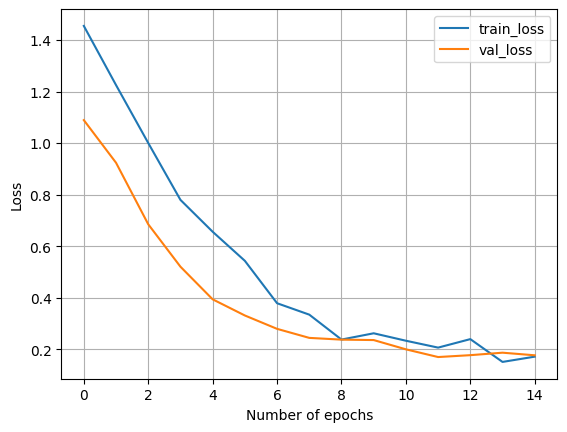

In [25]:
# Summarize history for loss
tr_losses = history.history['loss']
val_losses = history.history['val_loss']
tr_accs = history.history['accuracy']
val_accs = history.history['val_accuracy']
plt.plot(tr_losses, label = "train_loss")
plt.plot(val_losses, label = "val_loss")
plt.xlabel("Number of epochs")
plt.ylabel("Loss")
plt.grid()
plt.legend()
plt.show()

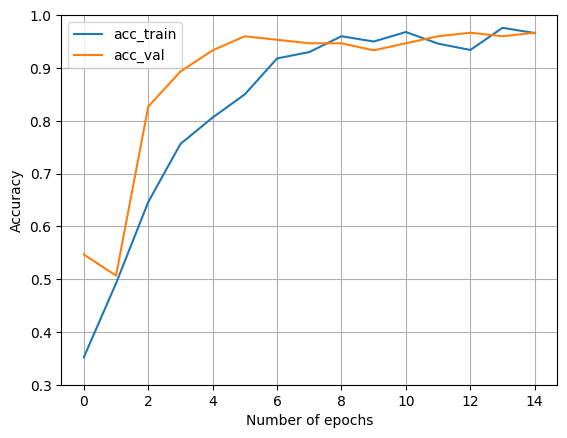

In [26]:
# Summarize history for accuracy
plt.plot(tr_accs, label = "acc_train")
plt.plot(val_accs, label = "acc_val")
plt.ylim((0.3, 1.))
plt.xlabel("Number of epochs")
plt.ylabel("Accuracy")
plt.grid()
plt.legend()
plt.show()

## Model Evaluation

We will now test the trained model on the test set containing the images the model has not seen.

In [27]:
# Prediction Function
predictions = model.predict(test_datagen, verbose = 1, steps = (len(test_datagen)))

2025-11-16 23:11:42.407170: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-16 23:11:42.527235: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-16 23:11:42.736740: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-16 23:11:42.859024: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-16 23:11:43.077134: E external/local_xla/xla/stream_

1163/1163 ━━━━━━━━━━━━━━━━━━━━ 30s 14ms/step


In [28]:
# Only save class with highest confidence for each image
predictions.squeeze().argmax(axis = 1)

array([0, 0, 0, ..., 4, 4, 4], shape=(1163,))

### Classification Report

The classification report shows the main classification metrics.

In [29]:
# Classification Report
print(classification_report(test_datagen.classes, predictions.squeeze().argmax(axis = 1)))

              precision    recall  f1-score   support

           0       0.98      0.93      0.95       268
           1       0.97      0.92      0.95       290
           2       0.94      0.98      0.96       169
           3       0.97      0.99      0.98       343
           4       0.81      0.94      0.87        93

    accuracy                           0.95      1163
   macro avg       0.93      0.95      0.94      1163
weighted avg       0.95      0.95      0.95      1163



### Confusion Matrix

Finally, we will construct the confusion matrix for the predictions obtained on the test set.

Confusion Matrix


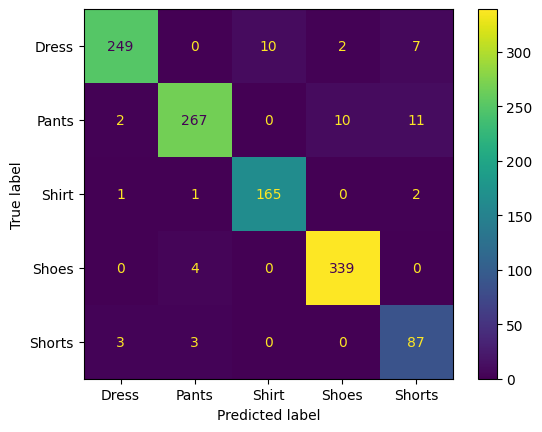

In [30]:
# Confusion Matrix
print('Confusion Matrix')
cm = confusion_matrix(test_datagen.classes, predictions.squeeze().argmax(axis = 1))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

disp = disp.plot(include_values = True,
                 values_format = 'd',
                 cmap = 'viridis',
                 ax = None,
                 xticks_rotation = 'horizontal')

plt.show()

## External Test Images

Let's try to visualize this results by testing our model on an image of each class .

In [34]:
def test(path):

  # Load the image using keras
  img = tf.keras.preprocessing.image.load_img(path,                                             
                                              color_mode = 'rgb',
                                              target_size = (224, 224, 3),
                                              interpolation = 'nearest')

  # Display the image
  plt.imshow(img)
  plt.axis('off')

  # Convert image to array for feeding it to the model
  img_array = np.asarray(img)

  # Expand dimension of img array
  img_array = np.expand_dims(img_array, 0)

  # Take prediction
  predictions = model.predict(img_array)

  # Evaluate Score
  score = predictions[0]

  return print('This image is a {} with a {:.2f} % confidence.'.format(classes[np.argmax(score)], 100 * np.max(score)))

### Download test images

In [32]:
# Download test images
!wget -O test-images.zip "https://www.dropbox.com/sh/2hpc50t687r0fdt/AADokyQsM-0kacFVl5KL-ONTa?dl=1"

# Extract images
!unzip -q -u test-images.zip

--2025-11-16 23:25:43--  https://www.dropbox.com/sh/2hpc50t687r0fdt/AADokyQsM-0kacFVl5KL-ONTa?dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.3.18, 2620:100:601b:18::a27d:812
Connecting to www.dropbox.com (www.dropbox.com)|162.125.3.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fo/92zbn8kq0029hyocdk5s1/AM_jAOMy47MuWklkW7ICt0w?rlkey=w6sel508cix1ehpf540m4ix9d&dl=1 [following]
--2025-11-16 23:25:43--  https://www.dropbox.com/scl/fo/92zbn8kq0029hyocdk5s1/AM_jAOMy47MuWklkW7ICt0w?rlkey=w6sel508cix1ehpf540m4ix9d&dl=1
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc69f32338ec96993af9cbf40829.dl.dropboxusercontent.com/zip_download_get/CYteE2VyVW2i5JQsUOcCMp9d62E9-y3ICQ1cRBLB1rwyDvlala9oRsA6aKU2F_lJsgsBg1pQKqsYviBcxcDYtBD4zPQo9JUa_T5LG_s4qG6YbA# [following]
--2025-11-16 23:25:44--  https://uc69f32338ec96993af9cbf40829.dl.dropboxusercontent.com/zip_

### Test Image 1

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
This image is a Dress with a 51.39 % confidence.


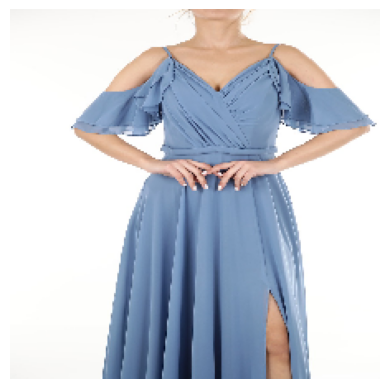

In [35]:
# Testing Image
test('test-image-1.jpg')

### Test Image 2

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
This image is a Shoes with a 56.47 % confidence.


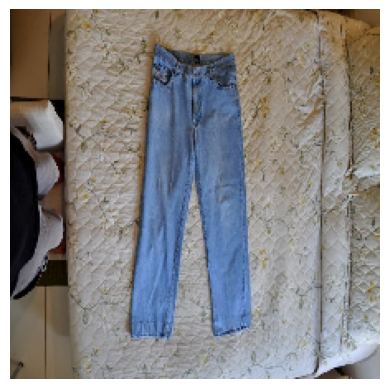

In [36]:
# Testing Image
test('test-image-2.jpg')

### Test Image 3

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
This image is a Shoes with a 95.67 % confidence.


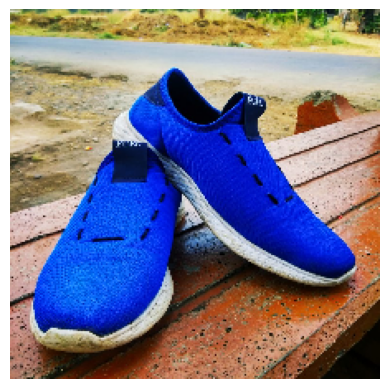

In [37]:
# Testing Image
test('test-image-3.jpg')

### Test Image 4

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
This image is a Shorts with a 64.30 % confidence.


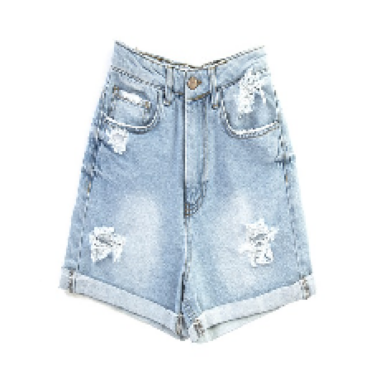

In [38]:
# Testing Image
test('test-image-4.jpg')

### Test Image 5

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
This image is a Shirt with a 98.11 % confidence.


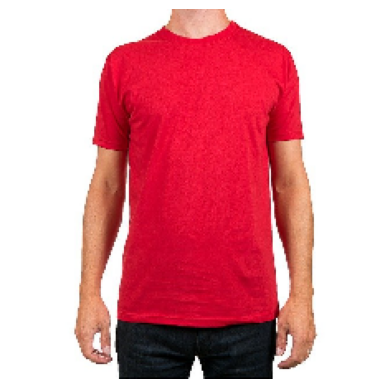

In [39]:
# Testing Image
test('test-image-5.jpg')

## Conclusion

We have successfully trained an image classifier for classifying five types of apparel. Despite using a minimal dataset, the model optimizes well to classify the various apparels.